Max Loss for With Pre-train: 0.6930
Max Loss for Without Pre-train: 0.6930
Max Loss for Extra Condition: 0.6931


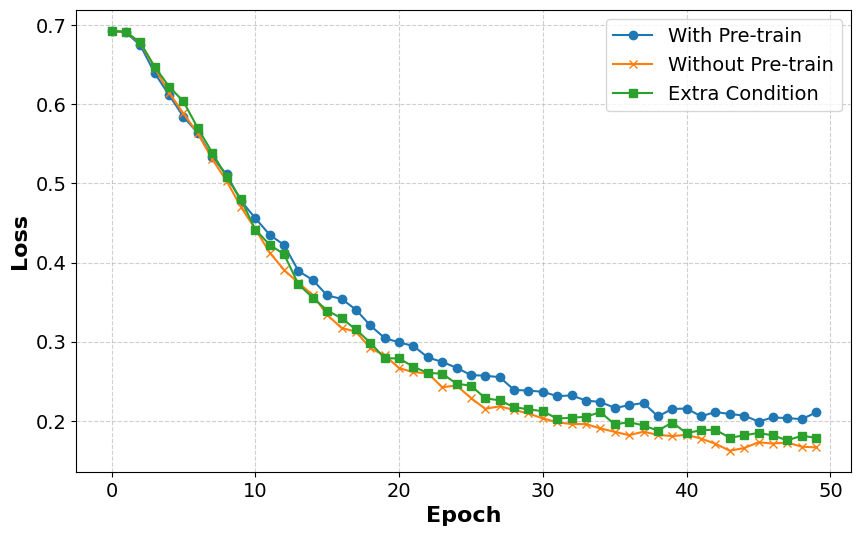

Max Loss for With Pre-train: 0.6921
Max Loss for Without Pre-train: 0.6927
Max Loss for Extra Condition: 1.4383


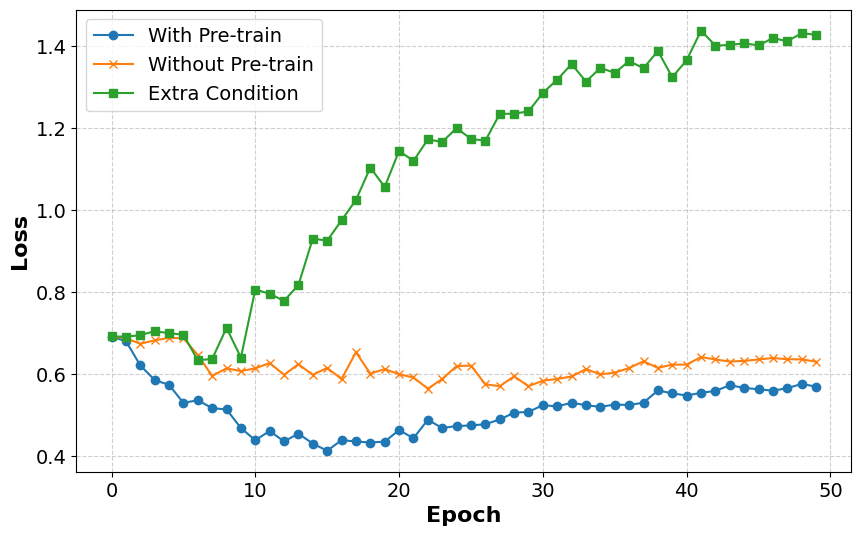

Max Loss for With Pre-train: 0.8654
Max Loss for Without Pre-train: 0.6925
Max Loss for Extra Condition: 1.6419


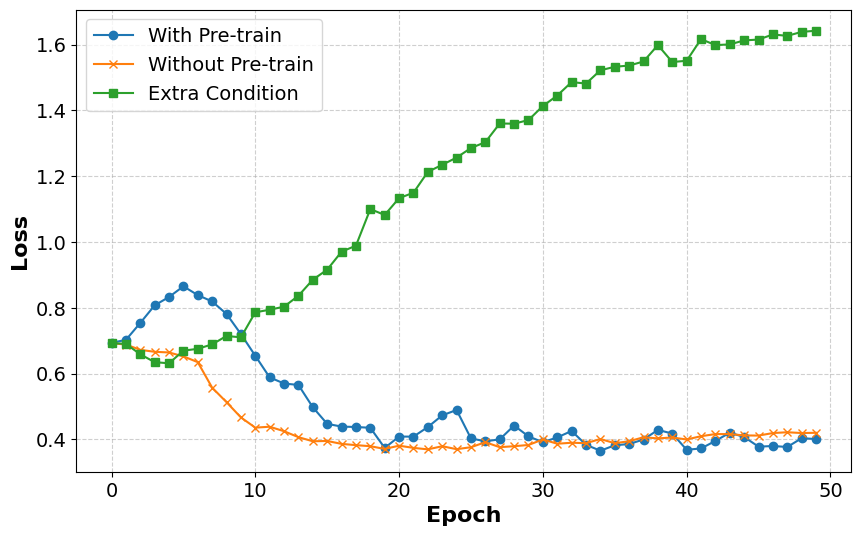

Max Accuracy for With Pre-train: 0.9241
Max Accuracy for Without Pre-train: 0.9395
Max Accuracy for Extra Condition: 0.9361


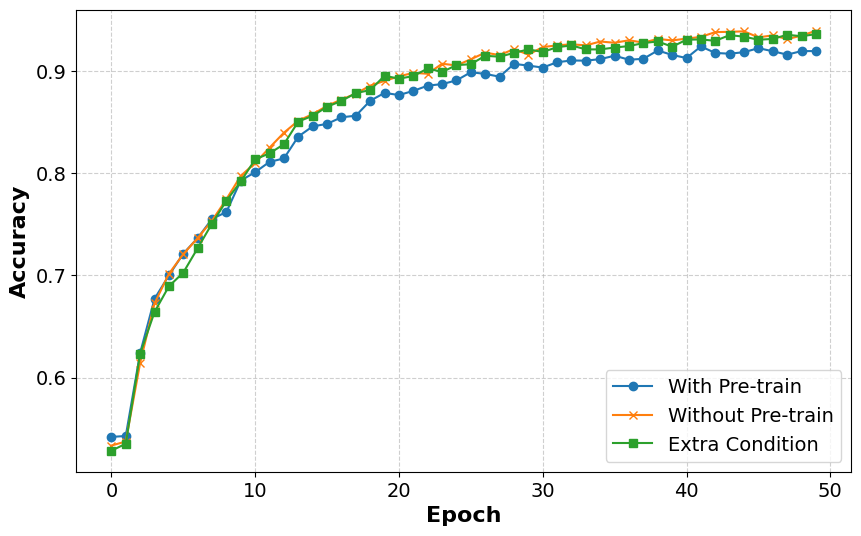

Max Accuracy for With Pre-train: 0.8214
Max Accuracy for Without Pre-train: 0.7917
Max Accuracy for Extra Condition: 0.6798


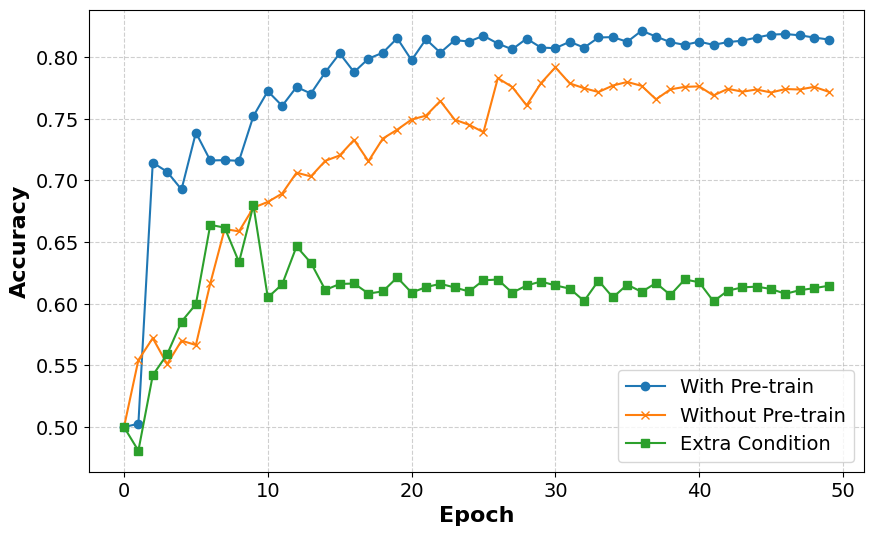

Max Balanced Accuracy for With Pre-train: 0.8541
Max Balanced Accuracy for Without Pre-train: 0.8734
Max Balanced Accuracy for Extra Condition: 0.6742


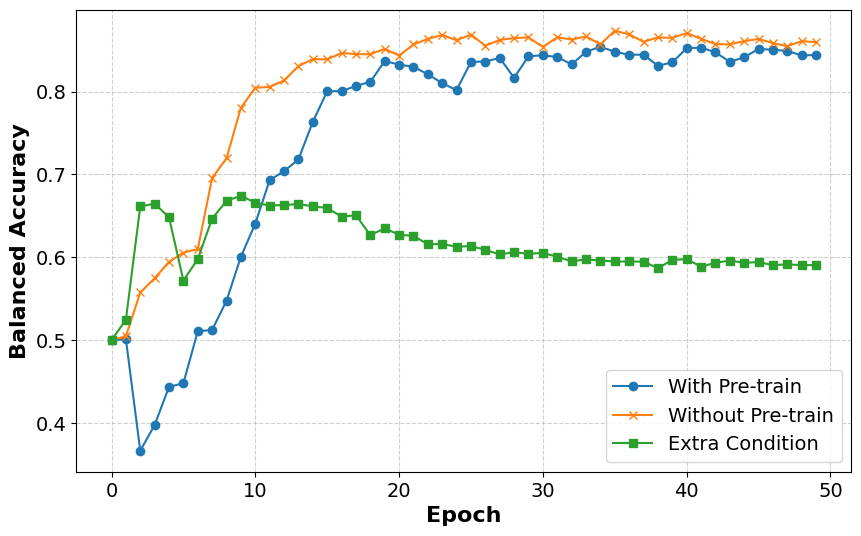

Max ROC AUC for With Pre-train: 0.9317
Max ROC AUC for Without Pre-train: 0.8665
Max ROC AUC for Extra Condition: 0.7809


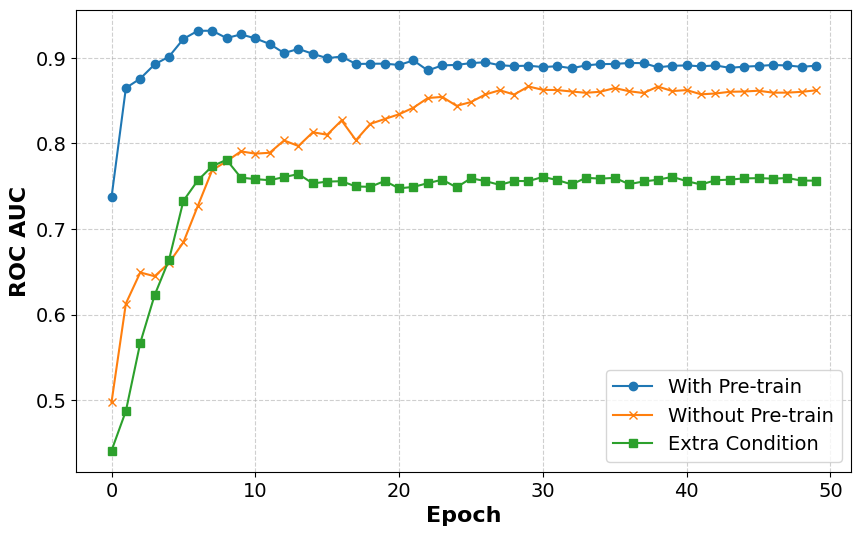

Max ROC AUC for With Pre-train: 0.9505
Max ROC AUC for Without Pre-train: 0.9149
Max ROC AUC for Extra Condition: 0.7662


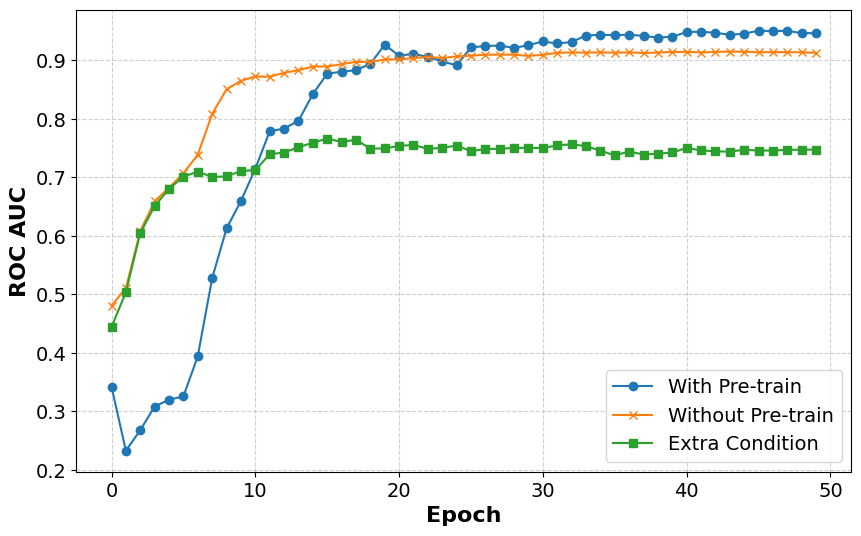

In [ ]:
import json
import matplotlib.pyplot as plt

# Function to extract metrics from a log file
def extract_metrics(log_file):
    epochs = []
    metrics = {
        'train_loss': [], 'val_loss': [], 'test_loss': [],
        'train_class_acc': [], 'val_accuracy': [], 'test_accuracy': [],
        'val_roc_auc': [], 'test_roc_auc': []
    }
    
    with open(log_file, 'r') as f:
        for line in f:
            entry = json.loads(line.strip())  # Parse each line as JSON
            epochs.append(entry['epoch'])
            metrics['train_loss'].append(entry['train_loss'])
            metrics['val_loss'].append(entry['val_loss'])
            metrics['test_loss'].append(entry['test_loss'])
            metrics['train_class_acc'].append(entry['train_class_acc'])
            metrics['val_accuracy'].append(entry['val_balanced_accuracy'])
            metrics['test_accuracy'].append(entry['test_balanced_accuracy'])
            metrics['val_roc_auc'].append(entry['val_roc_auc'])
            metrics['test_roc_auc'].append(entry['test_roc_auc'])
    
    return epochs, metrics

# Generalized plot function for multiple datasets
def plot_metric_comparison(epochs_list, y_values_list, ylabel, title, labels):
    plt.figure(figsize=(10, 6))
    
    # Define different markers and line styles for clarity
    markers = ['o', 'x', 's', '^']  # Adjust styles as needed
    line_styles = ['-', '--', '-.', ':']
    
    # Iterate through all datasets and plot them
    for i, (epochs, y_values, label) in enumerate(zip(epochs_list, y_values_list, labels)):
        max_y = max(y_values)
        print(f"Max {ylabel} for {label}: {max_y:.4f}")
        plt.plot(epochs, y_values, marker=markers[i % len(markers)], linestyle=line_styles[i % len(line_styles)], label=label)
    
    # Improve readability
    plt.xlabel('Epoch', fontsize=16, fontweight='bold')
    plt.ylabel(ylabel, fontsize=16, fontweight='bold')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.legend(fontsize=14, loc='best')
    
    plt.show()

# File paths to your log files
log_file1 = 'D:/LaBraM-main/checkpoints/finetune_stress_noleak_30chan_no400up_seed0/log.txt'
log_file2 = 'D:/LaBraM-main/checkpoints/finetune_stress_noleak_30chan_no400up_seed42/log.txt'
log_file3 = 'D:/LaBraM-main/checkpoints/finetune_stress_noleak_30chan_no400up_seed1/log.txt'  # Third log file
log_file4 = 'D:/LaBraM-main/checkpoints/finetune_stress_noleak_30chan_no400up_seed7/log.txt'  # Fourth log file

# Extract metrics from all logs
epochs1, metrics1 = extract_metrics(log_file1)
epochs2, metrics2 = extract_metrics(log_file2)
epochs3, metrics3 = extract_metrics(log_file3)
epochs4, metrics4 = extract_metrics(log_file4)

# Plot comparisons
plot_metric_comparison(
    [epochs1, epochs2, epochs3, epochs4], 
    [metrics1['test_accuracy'], metrics2['test_accuracy'], metrics3['test_accuracy'], metrics4['test_accuracy']], 
    'Balanced Accuracy', 'Test Balanced Accuracy over Epochs', 
    ['With Pre-train', 'Without Pre-train', 'Seed 43', 'Seed 44']
)

